10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
0 [D loss: 0.685660719871521, acc.: 60.625%] [G loss: 0.701861560344696]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step


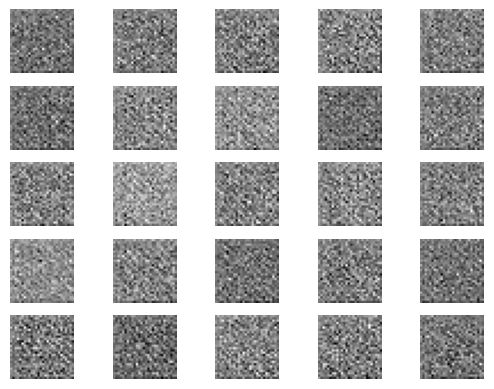

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [2]:
# 匯入必要的庫
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Dropout, Flatten, BatchNormalization, Reshape, Conv2D, Conv2DTranspose
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

# 設定隨機種子以確保結果可重複
np.random.seed(42)
tf.random.set_seed(42)

# 生成器模型定義
def build_generator():
    input_noise = Input(shape=(100,))  # 使用Input層定義輸入形狀
    x = Dense(7 * 7 * 256)(input_noise)  # 將輸入映射到7x7x256的張量
    x = BatchNormalization()(x)  # 加入批量正規化
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Reshape((7, 7, 256))(x)  # 重塑為7x7x256張量

    # 卷積轉置層將張量放大到14x14
    x = Conv2DTranspose(128, kernel_size=3, strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(negative_slope=0.2)(x)

    # 卷積轉置層將張量放大到28x28
    x = Conv2DTranspose(64, kernel_size=3, strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(negative_slope=0.2)(x)

    # 最後一層輸出28x28x1的灰度圖像
    output_image = Conv2D(1, kernel_size=3, padding="same", activation="tanh")(x)

    model = Model(input_noise, output_image)  # 使用Model構建生成器
    return model

# 判別器模型定義
def build_discriminator():
    input_image = Input(shape=(28, 28, 1))  # 使用Input層定義輸入形狀
    x = Conv2D(64, kernel_size=3, strides=2, padding="same")(input_image)  # 卷積層縮小特徵圖
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Dropout(0.3)(x)

    x = Conv2D(128, kernel_size=3, strides=2, padding="same")(x)  # 再次卷積縮小特徵圖
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Dropout(0.3)(x)

    x = Flatten()(x)  # 展平特徵圖
    output = Dense(1, activation='sigmoid')(x)  # 輸出層，判斷真假
    model = Model(input_image, output)  # 使用Model構建判別器
    return model

# 建立並編譯GAN模型
def build_gan(generator, discriminator):
    discriminator.trainable = False  # 訓練GAN時不更新判別器權重
    input_noise = Input(shape=(100,))
    generated_image = generator(input_noise)  # 生成器生成圖片
    validity = discriminator(generated_image)  # 判別器判斷圖片真假
    model = Model(input_noise, validity)  # 使用Model構建GAN
    return model

# 資料準備：載入MNIST資料集
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = (x_train.astype(np.float32) - 127.5) / 127.5  # 正規化到[-1, 1]
x_train = np.expand_dims(x_train, axis=-1)  # 擴展通道維度

# 初始化生成器與判別器
generator = build_generator()
discriminator = build_discriminator()

# 編譯判別器
discriminator.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5), metrics=['accuracy'])

# 編譯生成對抗網絡（GAN）
gan = build_gan(generator, discriminator)
gan.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5))

# 訓練GAN
def train_gan(epochs, batch_size, sample_interval):
    half_batch = batch_size // 2  # 一半用於真實數據，另一半用於生成數據

    for epoch in range(epochs):
        # 訓練判別器
        idx = np.random.randint(0, x_train.shape[0], half_batch)
        real_images = x_train[idx]  # 隨機選取真實數據
        noise = np.random.normal(0, 1, (half_batch, 100))  # 生成隨機噪聲
        fake_images = generator.predict(noise)  # 使用生成器生成數據

        # 標籤：真實數據為1，生成數據為0
        real_labels = np.ones((half_batch, 1))
        fake_labels = np.zeros((half_batch, 1))

        # 訓練判別器分辨真假數據
        d_loss_real = discriminator.train_on_batch(real_images, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)  # 平均損失

        # 訓練生成器
        noise = np.random.normal(0, 1, (batch_size, 100))  # 重新生成隨機噪聲
        valid_labels = np.ones((batch_size, 1))  # 生成器目標是讓判別器認為生成數據為真

        # 訓練GAN（實際上是在訓練生成器）
        g_loss = gan.train_on_batch(noise, valid_labels)

        # 每隔interval輸出訓練進度並保存生成圖片
        if epoch % sample_interval == 0:
            print(f"{epoch} [D loss: {d_loss[0]}, acc.: {100 * d_loss[1]}%] [G loss: {g_loss}]")
            sample_images(epoch)

# 保存生成的圖片
def sample_images(epoch):
    noise = np.random.normal(0, 1, (25, 100))  # 生成25個噪聲向量
    gen_images = generator.predict(noise)  # 使用生成器生成圖片

    # 調整圖片格式
    gen_images = 0.5 * gen_images + 0.5  # 將像素值從[-1, 1]轉換到[0, 1]

    # 繪製圖片
    fig, axs = plt.subplots(5, 5)
    cnt = 0
    for i in range(5):
        for j in range(5):
            axs[i, j].imshow(gen_images[cnt, :, :, 0], cmap='gray')
            axs[i, j].axis('off')
            cnt += 1
    plt.show()

# 開始訓練
train_gan(epochs=10, batch_size=640, sample_interval=1000)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


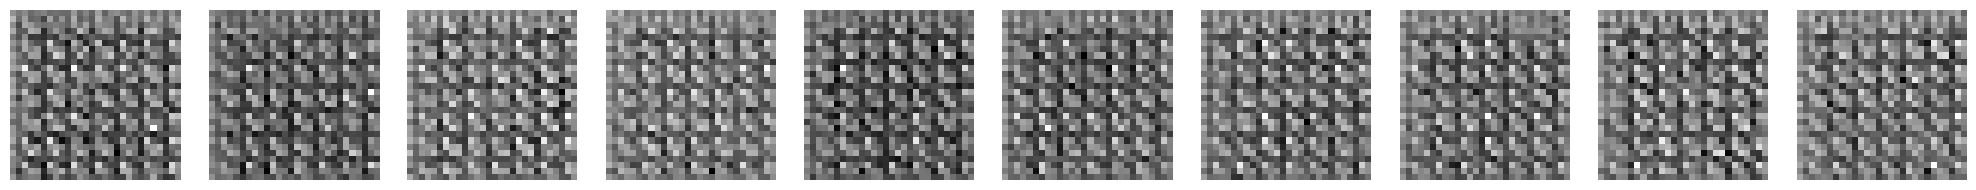

In [4]:
# prompt: 利用已生成的GAN模型產生照片，照片一次生成十張

import matplotlib.pyplot as plt
import numpy as np
# Generate 10 images
num_images_to_generate = 10
noise = np.random.normal(0, 1, (num_images_to_generate, 100))
generated_images = generator.predict(noise)

# Normalize the generated images to [0, 1] for display
generated_images = 0.5 * generated_images + 0.5

# Display the generated images
fig, axes = plt.subplots(1, num_images_to_generate, figsize=(num_images_to_generate * 2, 2))
for i in range(num_images_to_generate):
    axes[i].imshow(generated_images[i, :, :, 0], cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()
